In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
# import sklearn

In [2]:
!pip install numpy pandas matplotlib scikit-learn

In [3]:
df = pd.read_csv('highest_scores.csv')

In [4]:
df.head()

,Player,Country,Runs,Balls,Sr,Vs,4s,6s
0,Ibrahim Zadran,Afghanistan,177,146,121.23,England,12,6
1,Ben Duckett,England,165,143,115.38,Australia,17,3
2,Josh Inglis,Australia,120,86,139.53,England,8,6
3,Joe Root,England,120,111,108.11,Afghanistan,11,1
4,Tom Latham,New Zealand,118,104,113.46,Pakistan,10,3


In [5]:
df1 = df[['Balls', 'Runs']]

In [6]:
df1

,Balls,Runs
0,146,177
1,143,165
2,86,120
3,111,120
4,104,118
5,105,112
6,101,108
7,113,107
8,106,103
9,94,102


In [7]:
x = df1[['Balls']]    
y = df1['Runs']

In [8]:
model = LinearRegression()

In [9]:
model.fit(x,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [10]:
model.predict([[40]])

c:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([60.22351543])

In [11]:
w = model.coef_
b = model.intercept_
print(f' Coefficient (Weight): {w},\n Intercept (Bias): {b}')

 Coefficient (Weight): [0.79887648],
 Intercept (Bias): 28.268456225331903


In [12]:
print(f'LinearRegression : y = {w} * x + {b}')

LinearRegression : y = [0.79887648] * x + 28.268456225331903


In [13]:
y_pred = model.predict(x)

In [14]:
title_font = {
        'fontsize': 20, 'fontweight': 'bold',
        'color' : 'green'
}
label_font = {
        'fontsize': 15, 'fontweight': 'bold',
        'color' : 'red'
}

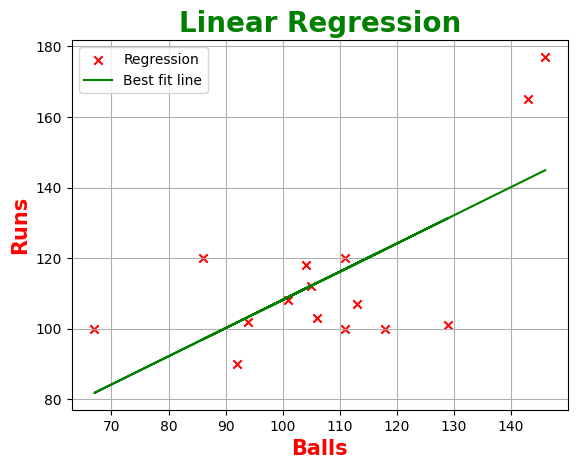

In [15]:
# 2D Visualization

plt.scatter(df1['Balls'], df1['Runs'], color='red',
        marker = 'x', label = 'Regression')
plt.plot(df1['Balls'],y_pred, label = 'Best fit line',
        color='green')
plt.xlabel('Balls', label_font)
plt.ylabel('Runs', label_font)
plt.title('Linear Regression', title_font)
plt.grid()
plt.legend()
plt.show()

# Multiple Linear Regression

In [16]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [17]:
# bat_stats = pd.read_csv('highest_scores.csv')
bowl_stats = pd.read_csv('bowler_stats.csv')

In [18]:
# bat_stats.head()

In [19]:
bowl_stats.head()

,Player,Matches,Overs,Balls,Wkts,Avg,Runs,4-fers,5-fers,Country
0,Matt Henry,4,31.2,188,10,16.70,167,-,1,New Zealand
1,Mohammed Shami,4,32.0,192,8,19.88,159,-,1,India
2,Varun Chakaravarthy,2,20.0,120,7,13.00,91,-,1,India
3,Mitchell Santner,4,40.0,240,7,27.71,194,-,-,New Zealand
4,Ben Dwarshuis,3,26.0,156,7,21.71,152,-,-,Australia


In [20]:
new_df = bowl_stats[['Matches', 'Overs','Balls']]
new_df.head()

,Matches,Overs,Balls
0,4,31.2,188
1,4,32.0,192
2,2,20.0,120
3,4,40.0,240
4,3,26.0,156


In [21]:
model = LinearRegression()

In [22]:
model.fit(new_df,bowl_stats['Wkts'])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
w = model.coef_
w

array([ 2.51179497,  3.59359844, -0.64186259])

In [24]:
b = model.intercept_
b

np.float64(5.9343584524626065)

In [25]:
model.predict([[4,10,24]])

c:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([36.51282061])

In [26]:
print(f'multiple Linear Regression : \ny = {w[0]} * x1 + {w[1]} * x2 + {w[2]} * x3 + {b}\n predicted value :{model.predict([[4,10,24]])[0]}')

multiple Linear Regression : 
y = 2.511794965573122 * x1 + 3.5935984384689874 * x2 + -0.6418625868621479 * x3 + 5.9343584524626065
 predicted value :36.512820614753416


c:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [1]:
import numpy as np
import pandas as pd     
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

In [2]:
def generate_data(n_points=100, w_true = 3, b_true = 5, noise = 6):
        x = np.linspace(0,10,n_points)
        y = w_true * x + b_true + np.random.normal(0,noise,n_points)
        return x,y

In [3]:
def cost_function(w,b, x, y):
        m =  len(x)
        y_pred = w * x + b
        mse = (1/2*m) *  np.sum((y-y_pred)**2)
        return mse

In [4]:
def gradient_mse(x, y, w, b):
        m = len(x)
        y_pred = w * x + b

        dw = (1/m) * np.sum((y - y_pred) * x)
        db = (1/m) * np.sum(y - y_pred)

        return dw, db

In [13]:
def gradient_descent(x,y, alpha =0.1, n_times =  100):

        w,b = 0.0,0.0
        w_history = []
        b_history = []

        cost_history = [cost_function(w,b,x,y)]
        
        for i in range(n_times):
                dw, db =  gradient_mse(x, y, w, b)

                w  = w + alpha * dw
                b = b + alpha * db

                w_history.append(w)
                b_history.append(b)

                cost = cost_function(w,b,x,y)
                cost_history.append(cost)

        return (w,b), np.array([w_history, b_history]), np.array(cost_history)

In [16]:
def visualization(x_data, y_data, w_final, b_final, path):

        fig = plt.figure(figsize=(15,7))

        # subplot 1
        ax1 = fig.add_subplot(1,2,1, projection ='3d')
        w_range = np.linspace(-10,15,50)
        b_range = np.linspace(-20, 30, 50)
        W,B = np.meshgrid(w_range, b_range)
        z = np.array([cost_function(w,b, x_data, y_data) 
                        for w,b in zip(W.ravel(), B.ravel())])
        Z  = z.reshape(W.shape)

        ax1.plot_surface(W, B, Z, cmap = 'viridis', alpha = 0.6)
        path_w,path_b = path[0], path[1]
        path_cost = np.array([cost_function(w,b,x_data,y_data) 
                        for w,b in zip(path_w, path_b)])
        ax1.plot(path_w, path_b, path_cost, color = 'r', 
                label = 'Gradient Descent Path')
        
        ax1.set_xlabel('Weight (w)')
        ax1.set_ylabel('Bias (b)')
        ax1.set_zlabel('Cost Function')

        # subplot 2
        ax2 = fig.add_subplot(1,2,2)
        ax2.scatter(x_data, y_data, color = 'r', marker ='x')
        ax2.plot(x_data, w_final*x_data + b_final, color = 'g')
        ax2.set_xlabel('x')
        ax2.set_ylabel('y')
        plt.tight_layout()
        plt.show()

        

Linear Regression Line : y = 3.450497255954761 * x + 1.1855678055602619


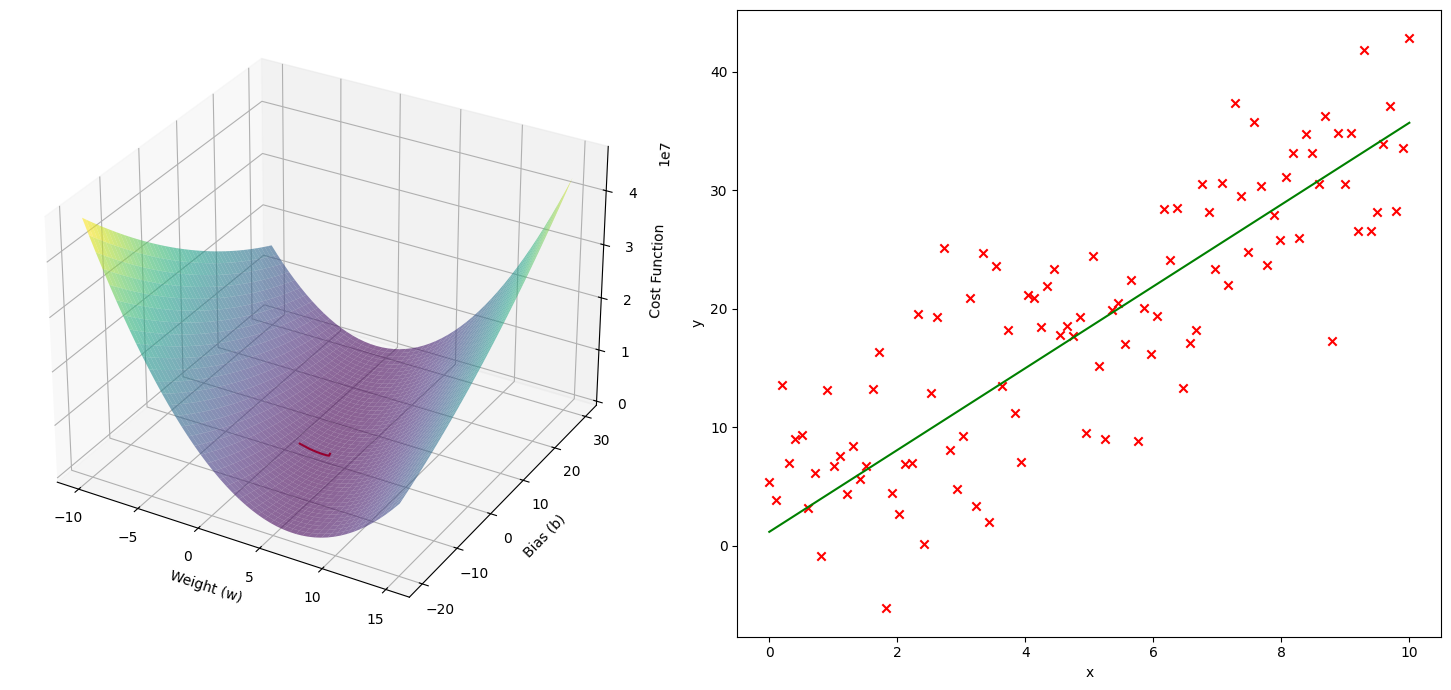

In [17]:
x_data, y_data = generate_data()
alpha = 0.01
n_times  = 100
final_params, history, cost_history = gradient_descent(x_data, y_data, alpha, n_times)
final_w, final_b = final_params

print(f'Linear Regression Line : y = {final_w} * x + {final_b}')

visualization(x_data, y_data, final_w, final_b, history)